# Lab Problem Statement 6 — Statistical Analysis of Palmer Penguins

**Objective:** Perform descriptive statistics, hypothesis testing, effect-size estimation, one-way ANOVA, Tukey HSD, Kruskal-Wallis, two-way ANOVA, and flipper-length analysis using the Palmer Penguins dataset..

## 1. Setup and Dataset

We use the `palmerpenguins` R package, which provides the Palmer Penguins dataset used in the lab statement.

In [1]:
# Install packages if needed
packages <- c("palmerpenguins", "dplyr", "ggplot2", "moments", "car", "effectsize")
new_packages <- packages[!(packages %in% installed.packages()[,"Package"])]
if(length(new_packages)) install.packages(new_packages, repos="https://cloud.r-project.org")

library(palmerpenguins)
library(dplyr)
library(ggplot2)
library(moments)
library(car)
library(effectsize)

data <- penguins

# Basic inspection
head(data)
dim(data)
str(data)
summary(data)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘bayestestR’, ‘insight’, ‘parameters’, ‘performance’, ‘datawizard’



Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode




species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


[1] 344   8

tibble [344 × 8] (S3: tbl_df/tbl/data.frame)
 $ species          : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island           : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ bill_length_mm   : num [1:344] 39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ bill_depth_mm    : num [1:344] 18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int [1:344] 181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int [1:344] 3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : Factor w/ 2 levels "female","male": 2 1 1 NA 1 2 1 2 NA NA ...
 $ year             : int [1:344] 2007 2007 2007 2007 2007 2007 2007 2007 2007 2007 ...


      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NAs    :2       NAs    :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NAs   : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NAs    :2         NAs    :2                  

## 2. Data Cleaning

For statistical tests involving body mass, sex, or flipper length, rows with missing values in the required variables are removed.

In [2]:
penguins_clean <- data %>%
  filter(!is.na(body_mass_g),
         !is.na(flipper_length_mm),
         !is.na(species),
         !is.na(sex))

cat("Original rows:", nrow(data), "\n")
cat("Complete rows for main analysis:", nrow(penguins_clean), "\n")

table(penguins_clean$species)
table(penguins_clean$sex)


Original rows: 344 
Complete rows for main analysis: 333 



   Adelie Chinstrap    Gentoo 
      146        68       119 


female   male 
   165    168 

## 3. Descriptive Statistical Analysis of Body Mass

Required measures: mean, median, minimum, maximum, variance, standard deviation, quartiles, IQR, skewness, and kurtosis.

In [3]:
# Overall descriptive statistics
body_mass_stats <- data %>%
  filter(!is.na(body_mass_g)) %>%
  summarise(
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g)
  )

body_mass_stats


Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4201.754,4050,2700,6300,643131.1,801.9545,3550,4750,1200,0.468264,2.273757


In [4]:
# Species-wise descriptive statistics
species_stats <- data %>%
  filter(!is.na(body_mass_g)) %>%
  group_by(species) %>%
  summarise(
    N = n(),
    Mean = mean(body_mass_g),
    Median = median(body_mass_g),
    Minimum = min(body_mass_g),
    Maximum = max(body_mass_g),
    Variance = var(body_mass_g),
    SD = sd(body_mass_g),
    Q1 = quantile(body_mass_g, 0.25),
    Q3 = quantile(body_mass_g, 0.75),
    IQR = IQR(body_mass_g),
    Skewness = skewness(body_mass_g),
    Kurtosis = kurtosis(body_mass_g),
    .groups = "drop"
  )

species_stats


species,N,Mean,Median,Minimum,Maximum,Variance,SD,Q1,Q3,IQR,Skewness,Kurtosis
<fct>,<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,151,3700.662,3700,2850,4775,210282.9,458.5661,3350.0,4000,650.0,0.28249381,2.405611
Chinstrap,68,3733.088,3700,2700,4800,147713.5,384.3351,3487.5,3950,462.5,0.24194125,3.463681
Gentoo,123,5076.016,5000,3950,6300,254133.2,504.1162,4700.0,5500,800.0,0.06878276,2.257871


### Interpretation

The table above provides the central tendency and dispersion of penguin body mass overall and separately by species. Comparing the species means, medians, and boxplot distributions helps identify whether some species are systematically heavier.

## 4. Visualizations — Body Mass

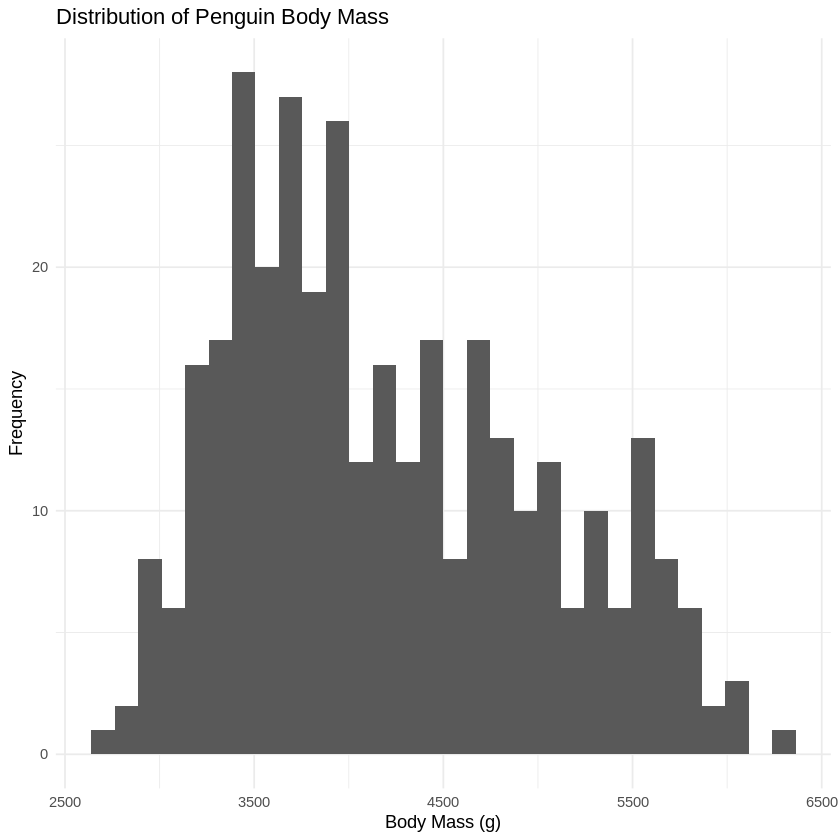

In [5]:
# Histogram
ggplot(data, aes(x = body_mass_g)) +
  geom_histogram(bins = 30, na.rm = TRUE) +
  labs(
    title = "Distribution of Penguin Body Mass",
    x = "Body Mass (g)",
    y = "Frequency"
  ) +
  theme_minimal()


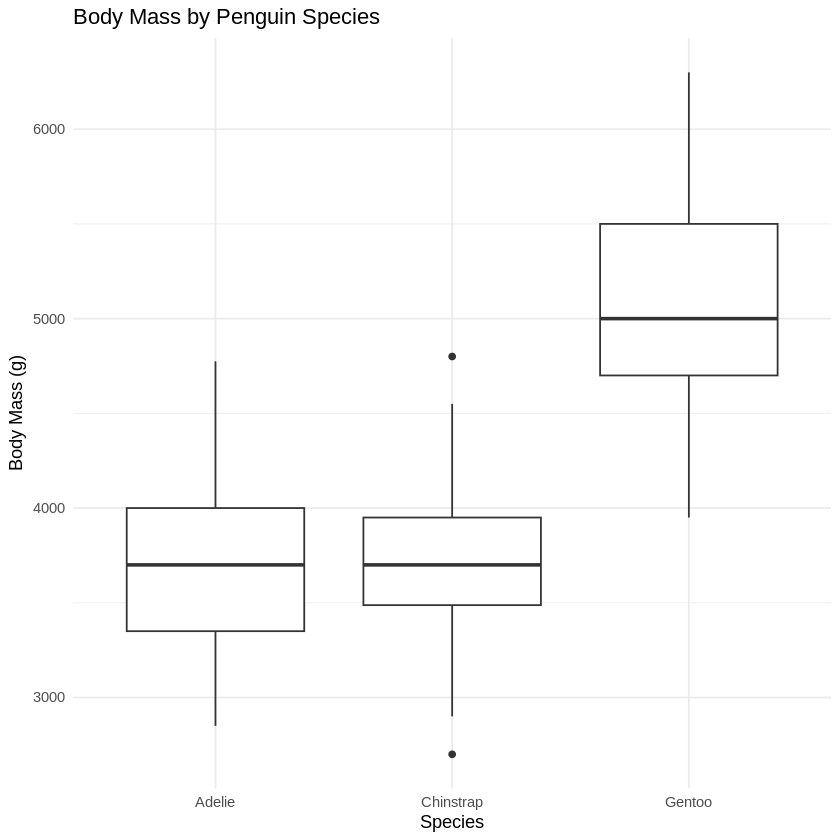

In [6]:
# Species-wise boxplot
ggplot(data, aes(x = species, y = body_mass_g)) +
  geom_boxplot(na.rm = TRUE) +
  labs(
    title = "Body Mass by Penguin Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()


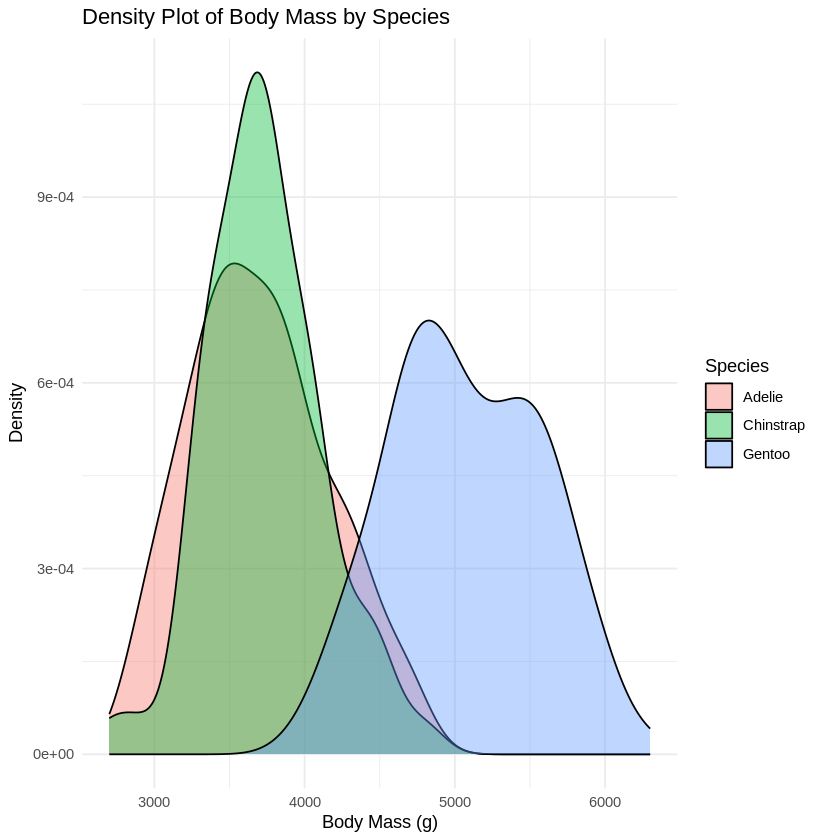

In [7]:
# Density plot
ggplot(data, aes(x = body_mass_g, fill = species)) +
  geom_density(alpha = 0.4, na.rm = TRUE) +
  labs(
    title = "Density Plot of Body Mass by Species",
    x = "Body Mass (g)",
    y = "Density",
    fill = "Species"
  ) +
  theme_minimal()


## 5. Hypothesis Testing — Male vs Female Body Mass

**H₀:** Mean body mass of male penguins equals mean body mass of female penguins.

**H₁:** Mean body mass of male penguins differs from mean body mass of female penguins.

We first inspect normality using Shapiro-Wilk tests and QQ-plots, then perform an independent two-sample Welch t-test.

In [8]:
sex_data <- data %>%
  filter(!is.na(body_mass_g), !is.na(sex))

# Shapiro-Wilk tests
shapiro_male <- shapiro.test(sex_data$body_mass_g[sex_data$sex == "male"])
shapiro_female <- shapiro.test(sex_data$body_mass_g[sex_data$sex == "female"])

shapiro_male
shapiro_female



	Shapiro-Wilk normality test

data:  sex_data$body_mass_g[sex_data$sex == "male"]
W = 0.92504, p-value = 1.227e-07



	Shapiro-Wilk normality test

data:  sex_data$body_mass_g[sex_data$sex == "female"]
W = 0.91931, p-value = 6.155e-08


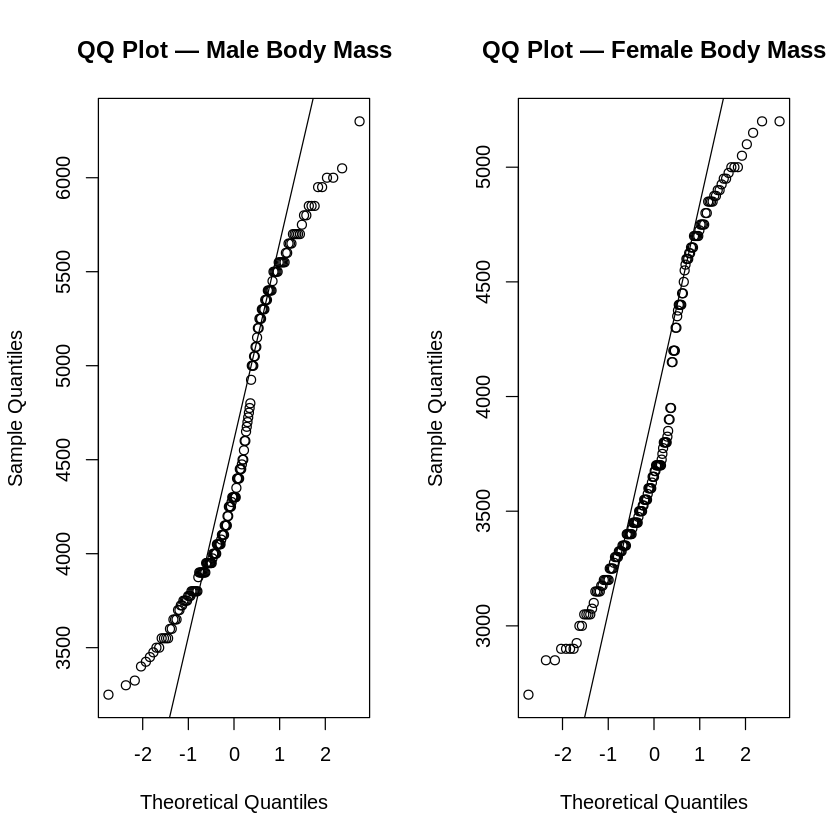

In [9]:
# QQ-plots
par(mfrow = c(1, 2))

qqnorm(sex_data$body_mass_g[sex_data$sex == "male"],
       main = "QQ Plot — Male Body Mass")
qqline(sex_data$body_mass_g[sex_data$sex == "male"])

qqnorm(sex_data$body_mass_g[sex_data$sex == "female"],
       main = "QQ Plot — Female Body Mass")
qqline(sex_data$body_mass_g[sex_data$sex == "female"])

par(mfrow = c(1, 1))


In [10]:
# Welch independent two-sample t-test
t_test <- t.test(
  body_mass_g ~ sex,
  data = sex_data,
  var.equal = FALSE,
  conf.level = 0.95
)

t_test



	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


In [11]:
# Cohen's d
cohen_d <- cohens_d(
  body_mass_g ~ sex,
  data = sex_data,
  pooled_sd = TRUE
)

cohen_d


Cohens_d,CI,CI_low,CI_high
<dbl>,<dbl>,<dbl>,<dbl>
-0.9362048,0.95,-1.161904,-0.709225


### Interpretation of the t-test

- If the p-value is below 0.05, reject H₀ and conclude that male and female mean body masses differ significantly.
- The 95% confidence interval gives the plausible range for the difference in population means.
- Cohen's *d* describes the magnitude of the difference: approximately 0.2 = small, 0.5 = medium, and 0.8 = large effect as a common rule of thumb.

## 6. One-Way ANOVA — Body Mass Across Species

Model:

`body_mass_g ~ species`

Before ANOVA, we examine distributions, normality, and homogeneity of variance.

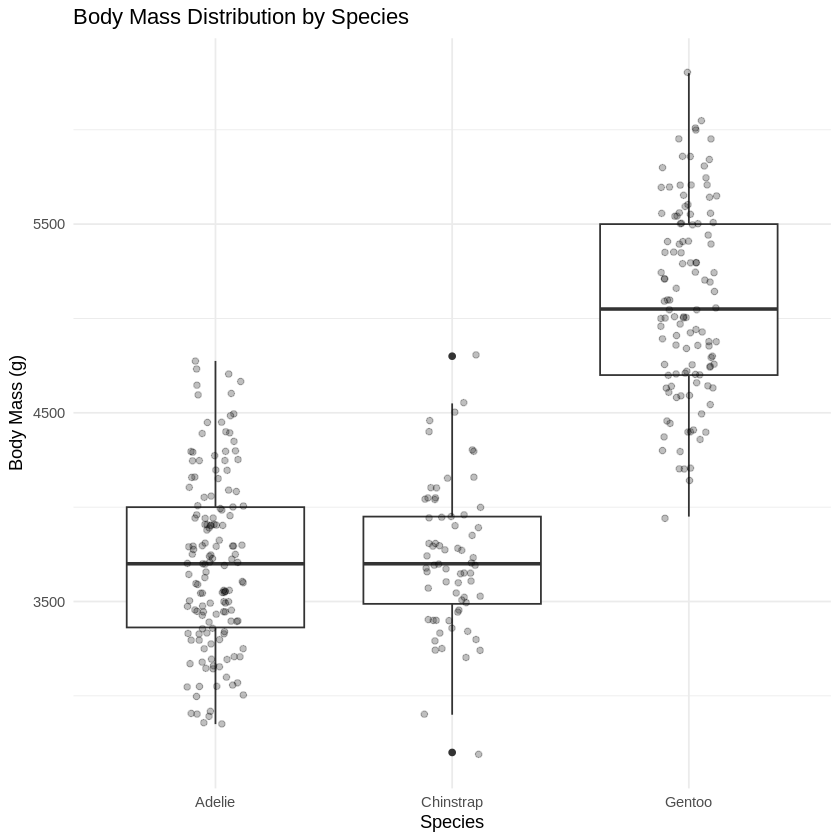

In [12]:
# Distribution by species
ggplot(penguins_clean, aes(x = species, y = body_mass_g)) +
  geom_boxplot() +
  geom_jitter(width = 0.12, alpha = 0.25) +
  labs(
    title = "Body Mass Distribution by Species",
    x = "Species",
    y = "Body Mass (g)"
  ) +
  theme_minimal()


In [13]:
# Shapiro-Wilk normality test within each species
by(penguins_clean$body_mass_g,
   penguins_clean$species,
   shapiro.test)


penguins_clean$species: Adelie

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98116, p-value = 0.04232

------------------------------------------------------------ 
penguins_clean$species: Chinstrap

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98449, p-value = 0.5605

------------------------------------------------------------ 
penguins_clean$species: Gentoo

	Shapiro-Wilk normality test

data:  dd[x, ]
W = 0.98606, p-value = 0.2605


In [14]:
# Levene's test for homogeneity of variance
levene_result <- leveneTest(body_mass_g ~ species, data = penguins_clean)
levene_result


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,2,5.134899,0.006367054
,330,NA,NA


In [15]:
# One-way ANOVA
anova_one <- aov(body_mass_g ~ species, data = penguins_clean)
summary(anova_one)


             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = penguins_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000


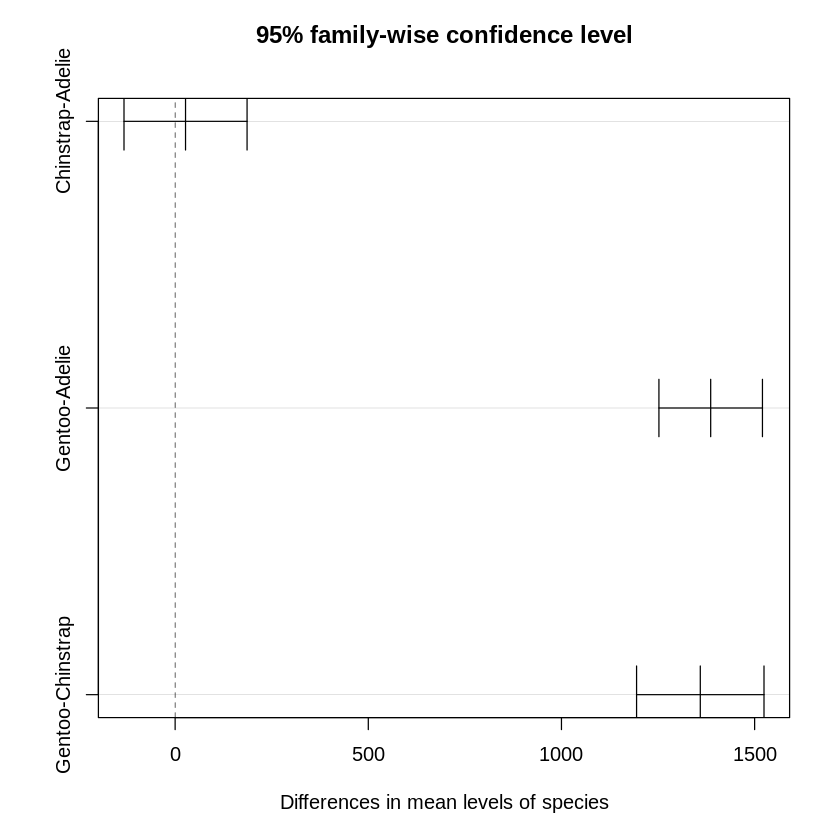

In [16]:
# Tukey HSD post-hoc comparison
tukey_result <- TukeyHSD(anova_one)
tukey_result
plot(tukey_result)


### One-Way ANOVA Interpretation

The ANOVA tests whether all three species have the same population mean body mass. If the ANOVA p-value is below 0.05, the null hypothesis is rejected and at least one species mean differs.

Tukey HSD identifies the specific species pairs responsible for the significant overall result.

## 7. Non-Parametric Analysis — Kruskal-Wallis

If ANOVA assumptions are substantially violated, the Kruskal-Wallis test provides a non-parametric alternative for comparing the distributions across the three species.

In [17]:
kruskal_result <- kruskal.test(body_mass_g ~ species, data = penguins_clean)
kruskal_result



	Kruskal-Wallis rank sum test

data:  body_mass_g by species
Kruskal-Wallis chi-squared = 212.09, df = 2, p-value < 2.2e-16


In [18]:
# Side-by-side summary of p-values
anova_p <- summary(anova_one)[[1]][["Pr(>F)"]][1]
kruskal_p <- kruskal_result$p.value

cat("One-way ANOVA p-value:", anova_p, "\n")
cat("Kruskal-Wallis p-value:", kruskal_p, "\n")


One-way ANOVA p-value: 3.744505e-81 
Kruskal-Wallis p-value: 8.836877e-47 


### Comparison

If both p-values are below 0.05, both parametric and non-parametric analyses support the conclusion that body mass differs among species. If their conclusions differ, the assumptions and the nature of the distributions should be examined more carefully.

## 8. Two-Way ANOVA — Species and Sex

Model:

`body_mass_g ~ species * sex`

The interaction term tests whether the effect of sex on body mass depends on penguin species.

In [19]:
two_way <- aov(body_mass_g ~ species * sex, data = penguins_clean)
summary(two_way)


             Df    Sum Sq  Mean Sq F value   Pr(>F)    
species       2 145190219 72595110 758.358  < 2e-16 ***
sex           1  37090262 37090262 387.460  < 2e-16 ***
species:sex   2   1676557   838278   8.757 0.000197 ***
Residuals   327  31302628    95727                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

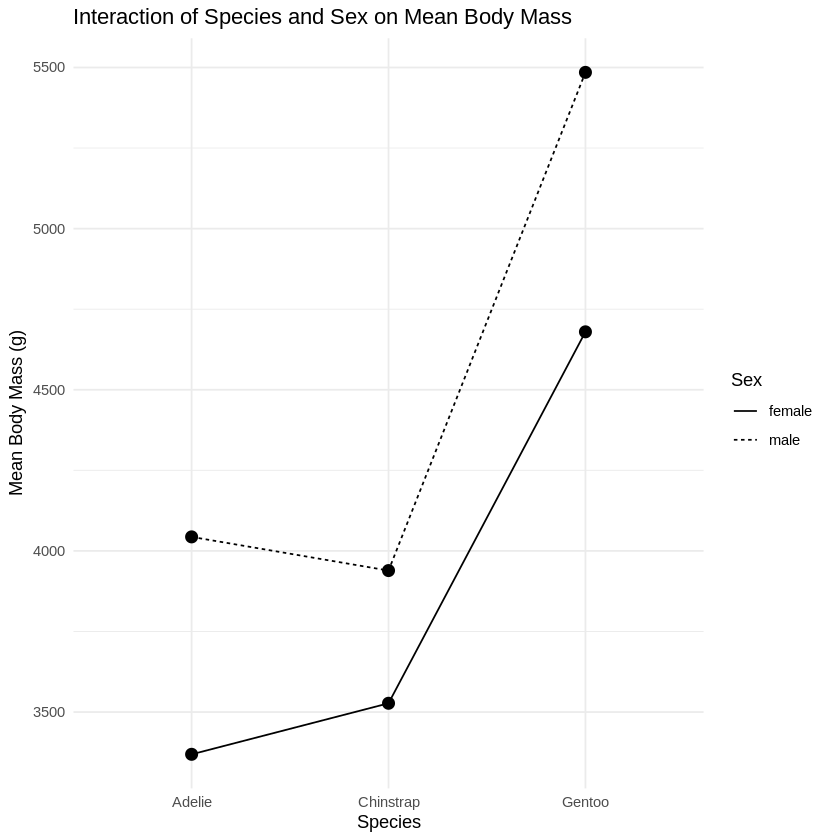

In [20]:
# Interaction visualization
ggplot(penguins_clean,
       aes(x = species, y = body_mass_g, group = sex, linetype = sex)) +
  stat_summary(fun = mean, geom = "line") +
  stat_summary(fun = mean, geom = "point", size = 3) +
  labs(
    title = "Interaction of Species and Sex on Mean Body Mass",
    x = "Species",
    y = "Mean Body Mass (g)",
    linetype = "Sex"
  ) +
  theme_minimal()


### Two-Way ANOVA Interpretation

Report the p-values for:

1. **Species main effect** — whether mean body mass differs by species.
2. **Sex main effect** — whether mean body mass differs by sex.
3. **Species × Sex interaction** — whether the sex difference changes across species.

A significant interaction should be interpreted before relying on the main effects alone.

## 9. Additional Analysis — Flipper Length

We repeat the species comparison using `flipper_length_mm`.

In [21]:
flipper_data <- data %>%
  filter(!is.na(flipper_length_mm), !is.na(species))

# Descriptive statistics
flipper_stats <- flipper_data %>%
  group_by(species) %>%
  summarise(
    N = n(),
    Mean = mean(flipper_length_mm),
    Median = median(flipper_length_mm),
    SD = sd(flipper_length_mm),
    Minimum = min(flipper_length_mm),
    Maximum = max(flipper_length_mm),
    IQR = IQR(flipper_length_mm),
    .groups = "drop"
  )

flipper_stats


species,N,Mean,Median,SD,Minimum,Maximum,IQR
<fct>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>
Adelie,151,189.9536,190,6.539457,172,210,9
Chinstrap,68,195.8235,196,7.131894,178,212,10
Gentoo,123,217.1870,216,6.484976,203,231,9


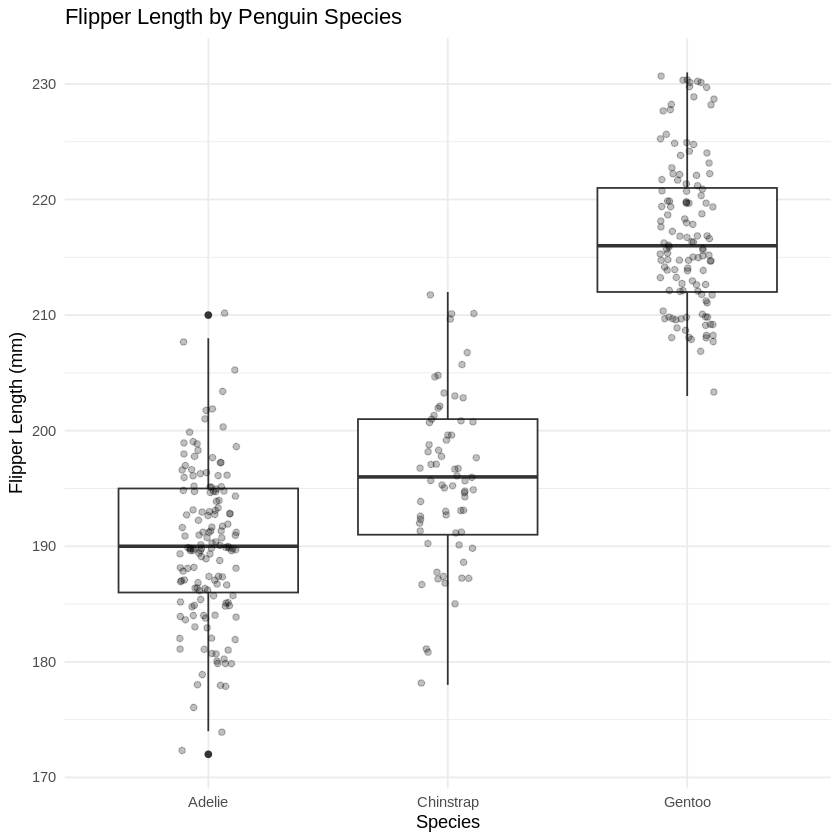

In [22]:
# Species-wise flipper length comparison
ggplot(flipper_data, aes(x = species, y = flipper_length_mm)) +
  geom_boxplot() +
  geom_jitter(width = 0.12, alpha = 0.25) +
  labs(
    title = "Flipper Length by Penguin Species",
    x = "Species",
    y = "Flipper Length (mm)"
  ) +
  theme_minimal()


In [23]:
# One-way ANOVA for flipper length
flipper_anova <- aov(flipper_length_mm ~ species, data = flipper_data)
summary(flipper_anova)

# Tukey HSD
TukeyHSD(flipper_anova)


             Df Sum Sq Mean Sq F value Pr(>F)    
species       2  52473   26237   594.8 <2e-16 ***
Residuals   339  14953      44                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = flipper_length_mm ~ species, data = flipper_data)

$species
                      diff       lwr       upr p adj
Chinstrap-Adelie  5.869887  3.586583  8.153191     0
Gentoo-Adelie    27.233349 25.334376 29.132323     0
Gentoo-Chinstrap 21.363462 19.000841 23.726084     0


## 10. Group Comparison Plot with Means and 95% CI

In [24]:
# Calculate mean and 95% CI by species
flipper_ci <- flipper_data %>%
  group_by(species) %>%
  summarise(
    n = n(),
    mean = mean(flipper_length_mm),
    sd = sd(flipper_length_mm),
    se = sd / sqrt(n),
    lower = mean - qt(0.975, df = n - 1) * se,
    upper = mean + qt(0.975, df = n - 1) * se,
    .groups = "drop"
  )

flipper_ci


species,n,mean,sd,se,lower,upper
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adelie,151,189.9536,6.539457,0.5321735,188.9021,191.0052
Chinstrap,68,195.8235,7.131894,0.8648692,194.0972,197.5498
Gentoo,123,217.1870,6.484976,0.5847306,216.0295,218.3445


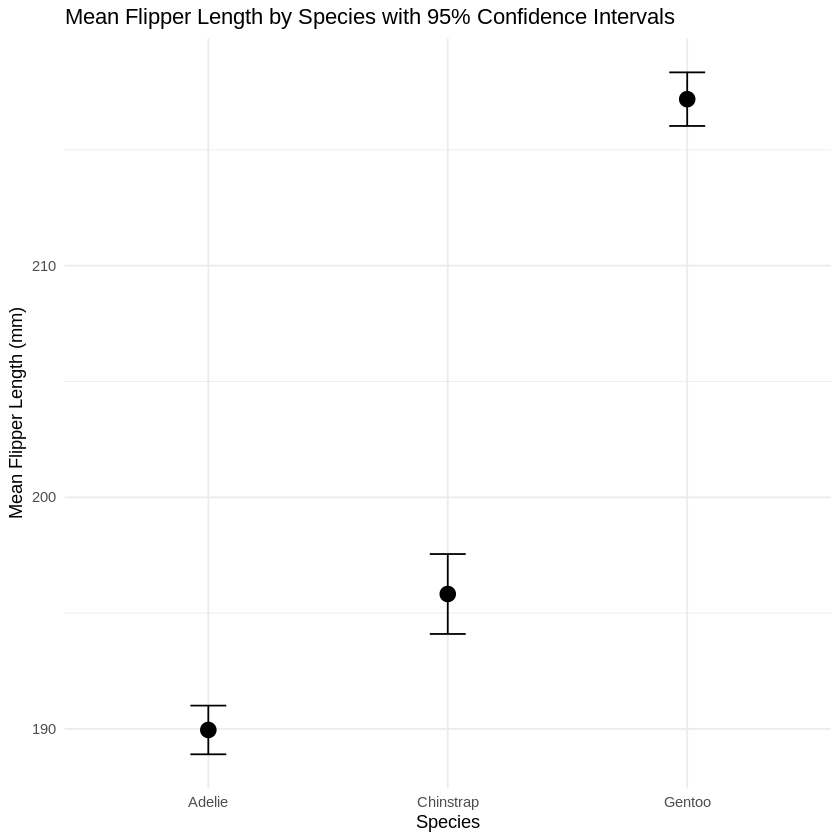

In [25]:
ggplot(flipper_ci, aes(x = species, y = mean)) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15) +
  labs(
    title = "Mean Flipper Length by Species with 95% Confidence Intervals",
    x = "Species",
    y = "Mean Flipper Length (mm)"
  ) +
  theme_minimal()


## 11.Statistical Summary


In [26]:
cat("===== FINAL STATISTICAL SUMMARY =====\n\n")

cat("1. Body Mass Overall Descriptive Statistics\n")
print(body_mass_stats)

cat("\n2. Body Mass by Species\n")
print(species_stats)

cat("\n3. Male vs Female Welch t-test\n")
cat("t =", unname(t_test$statistic),
    ", df =", unname(t_test$parameter),
    ", p-value =", t_test$p.value, "\n")
cat("95% CI: ", t_test$conf.int[1], " to ", t_test$conf.int[2], "\n")

cat("\n4. Cohen's d\n")
print(cohen_d)

cat("\n5. One-Way ANOVA: Body Mass ~ Species\n")
print(summary(anova_one))

cat("\n6. Tukey HSD\n")
print(tukey_result)

cat("\n7. Kruskal-Wallis\n")
print(kruskal_result)

cat("\n8. Two-Way ANOVA: Body Mass ~ Species * Sex\n")
print(summary(two_way))

cat("\n9. Flipper Length ANOVA\n")
print(summary(flipper_anova))

cat("\n10. Flipper Length Tukey HSD\n")
print(TukeyHSD(flipper_anova))


===== FINAL STATISTICAL SUMMARY =====

1. Body Mass Overall Descriptive Statistics
# A tibble: 1 × 11
   Mean Median Minimum Maximum Variance    SD    Q1    Q3   IQR Skewness
  <dbl>  <dbl>   <int>   <int>    <dbl> <dbl> <dbl> <dbl> <dbl>    <dbl>
1 4202.   4050    2700    6300  643131.  802.  3550  4750  1200    0.468
# ℹ 1 more variable: Kurtosis <dbl>

2. Body Mass by Species
# A tibble: 3 × 13
  species       N  Mean Median Minimum Maximum Variance    SD    Q1    Q3   IQR
  <fct>     <int> <dbl>  <dbl>   <int>   <int>    <dbl> <dbl> <dbl> <dbl> <dbl>
1 Adelie      151 3701.   3700    2850    4775  210283.  459. 3350   4000  650 
2 Chinstrap    68 3733.   3700    2700    4800  147713.  384. 3488.  3950  462.
3 Gentoo      123 5076.   5000    3950    6300  254133.  504. 4700   5500  800 
# ℹ 2 more variables: Skewness <dbl>, Kurtosis <dbl>

3. Male vs Female Welch t-test
t = -8.554537 , df = 323.8959 , p-value = 4.793891e-16 
95% CI:  -840.5783  to  -526.2453 

4. Cohen's d
Cohen's d